## 1. Setup
Import the core Python libraries used throughout this analysis:
- **pandas** — data manipulation and analysis (equivalent to Excel in Python)
- **numpy** — numerical calculations
- **matplotlib** — data visualisation
- **warnings** — suppress minor output messages for clean notebook display

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import os

os.chdir(Path(__file__).parent if '__file__' in dir() else Path().resolve())

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

BLUE   = '#1f4e79'
ORANGE = '#c55a11'
RED    = '#c00000'
GREEN  = '#375623'

print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load Dataset
Load the Home Credit Default Risk dataset — 307,511 loan applications 
from a consumer finance company. Each row is one applicant. The target 
variable `TARGET` tells us the outcome: 1 = defaulted, 0 = repaid.

**Business context:** The overall default rate of 8.1% is double the 
Bank of Uganda's acceptable NPA threshold of 4%, indicating a portfolio 
under significant credit stress.

In [2]:
df = pd.read_csv("application_train.csv")

print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
print(f"\nDefault rate: {df['TARGET'].mean():.1%}")
print(f"Defaulted loans: {df['TARGET'].sum():,}")
print(f"Good loans: {(df['TARGET']==0).sum():,}")

Rows: 307,511 | Columns: 122

Default rate: 8.1%
Defaulted loans: 24,825
Good loans: 282,686


## 3. First Look at the Data
Preview the first 5 rows to confirm the data loaded correctly and 
values look sensible before any analysis begins. This is standard 
practice — never trust a dataset without inspecting it first.

In [3]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Statistical Summary
Generate descriptive statistics for key credit variables.

**Key observations:**
- `DAYS_BIRTH` is stored as negative days from application date — 
  must be converted to age in years using `abs(DAYS_BIRTH) / 365`
- `DAYS_EMPLOYED` contains a sentinel value of 365,243 (= 1,000 years) 
  representing non-employed applicants (pensioners, students, unemployed)
  — a common pattern in core banking system exports
- `AMT_INCOME_TOTAL` shows scientific notation due to large values — 
  confirms we are working with real currency amounts

In [4]:
# Check key credit variables
credit_cols = ['TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 
               'AMT_ANNUITY', 'AMT_GOODS_PRICE',
               'NAME_CONTRACT_TYPE', 'CODE_GENDER',
               'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
               'DAYS_BIRTH', 'DAYS_EMPLOYED']

print(df[credit_cols].describe().round(2).to_string())

          TARGET  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  DAYS_BIRTH  DAYS_EMPLOYED
count  307511.00      3.075110e+05   307511.00    307499.00        307233.00   307511.00      307511.00
mean        0.08      1.687979e+05   599026.00     27108.57        538396.21   -16037.00       63815.05
std         0.27      2.371231e+05   402490.78     14493.74        369446.46     4363.99      141275.77
min         0.00      2.565000e+04    45000.00      1615.50         40500.00   -25229.00      -17912.00
25%         0.00      1.125000e+05   270000.00     16524.00        238500.00   -19682.00       -2760.00
50%         0.00      1.471500e+05   513531.00     24903.00        450000.00   -15750.00       -1213.00
75%         0.00      2.025000e+05   808650.00     34596.00        679500.00   -12413.00        -289.00
max         1.00      1.170000e+08  4050000.00    258025.50       4050000.00    -7489.00      365243.00


## 5. Feature Engineering — Age and Employment
Convert raw day-based columns into meaningful business variables:

- `AGE_YEARS` — applicant age in years (more intuitive than negative days)
- `IS_NOT_EMPLOYED` — binary flag (1 = not formally employed) derived 
  from the 365,243 sentinel value. Treated as a separate category rather 
  than missing data because it carries meaningful credit risk information
- `EMPLOYMENT_YEARS` — years in current employment for employed 
  applicants only

**Banking rationale:** Employment stability is a primary repayment 
capacity indicator. At DFCU Bank, employment verification was a 
mandatory step in all salary loan approvals.

In [5]:
# How many applicants have this sentinel value?
print((df['DAYS_EMPLOYED'] == 365243).sum())
print(f"That is {(df['DAYS_EMPLOYED'] == 365243).mean():.1%} of applicants")

55374
That is 18.0% of applicants


In [6]:
# Convert DAYS_BIRTH to age in years (more intuitive)
df['AGE_YEARS'] = (df['DAYS_BIRTH'].abs() / 365).round(1)

# Flag non-employed applicants (sentinel value)
df['IS_NOT_EMPLOYED'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)

# For employed applicants, convert to years of employment
df['EMPLOYMENT_YEARS'] = np.where(
    df['DAYS_EMPLOYED'] == 365243,
    np.nan,
    (df['DAYS_EMPLOYED'].abs() / 365).round(1)
)

print(f"Age range: {df['AGE_YEARS'].min()} to {df['AGE_YEARS'].max()} years")
print(f"Non-employed applicants: {df['IS_NOT_EMPLOYED'].sum():,} ({df['IS_NOT_EMPLOYED'].mean():.1%})")
print(f"\nAvg employment years (employed only): "
      f"{df['EMPLOYMENT_YEARS'].mean():.1f} years")

Age range: 20.5 to 69.1 years
Non-employed applicants: 55,374 (18.0%)

Avg employment years (employed only): 6.5 years


## 6. Default Rate by Employment Status
Compare default rates between employed and non-employed applicants.

**Important:** we compare default *rates* (%), not absolute counts. 
Employed applicants dominate the portfolio at 82% of volume, so their 
raw default count will always be higher — the rate removes this 
volume bias and gives a fair comparison.

**Finding:** the non-employed group's lower default rate is partly 
explained by pensioners — who have guaranteed pension income, smaller 
loan amounts, and conservative borrowing behaviour — pulling the rate down.

In [7]:
emp_default = df.groupby('IS_NOT_EMPLOYED')['TARGET'].agg(['mean','count','sum'])
emp_default.index = ['Employed', 'Not Employed']
emp_default.columns = ['default_rate', 'total_applicants', 'defaults']
emp_default['default_rate'] = (emp_default['default_rate'] * 100).round(1)

print("=== DEFAULT RATE BY EMPLOYMENT STATUS ===")
print(emp_default.to_string())

=== DEFAULT RATE BY EMPLOYMENT STATUS ===
              default_rate  total_applicants  defaults
Employed               8.7            252137     21835
Not Employed           5.4             55374      2990


In [8]:
print("=== DEFAULT RATE BY INCOME TYPE ===")
income_default = (df.groupby('NAME_INCOME_TYPE')['TARGET']
                  .agg(['mean','count','sum'])
                  .rename(columns={'mean':'default_rate',
                                   'count':'applicants',
                                   'sum':'defaults'})
                  .assign(default_rate=lambda x: 
                          (x.default_rate*100).round(1))
                  .sort_values('default_rate', ascending=False))

print(income_default.to_string())

=== DEFAULT RATE BY INCOME TYPE ===
                      default_rate  applicants  defaults
NAME_INCOME_TYPE                                        
Maternity leave               40.0           5         2
Unemployed                    36.4          22         8
Working                        9.6      158774     15224
Commercial associate           7.5       71617      5360
State servant                  5.8       21703      1249
Pensioner                      5.4       55362      2982
Businessman                    0.0          10         0
Student                        0.0          18         0


## 7. Default Rate by Income Type
Break down the non-employed category further to identify which specific 
income types carry the highest default risk.

**Critical finding — Maternity Leave (40% default rate):**
Applicants on maternity leave are classified as employed but have 
temporarily suspended income. A 40% default rate — nearly 5x the 
portfolio average — indicates the bank's credit policy was not 
screening for income interruption risk at the time of approval.

**Recommendation:** loan applications from applicants on maternity 
leave should trigger enhanced due diligence, require a co-borrower, 
or include a built-in repayment holiday.

**Unemployed applicants (36% default, 22 cases):**
Approval of loans to applicants with no income source suggests credit 
policy exceptions were granted without adequate compensating controls 
— a finding that would be escalated in an internal audit review.

In [9]:
print("=== LOAN AMOUNT BY DEFAULT STATUS ===")
loan_analysis = df.groupby('TARGET').agg(
    avg_loan    =('AMT_CREDIT','mean'),
    avg_income  =('AMT_INCOME_TOTAL','mean'),
    avg_annuity =('AMT_ANNUITY','mean'),
    count       =('TARGET','count')
).round(2)

loan_analysis.index = ['Good Loan','Defaulted']
print(loan_analysis.to_string())

# Debt to income ratio
df['DEBT_TO_INCOME'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
print(f"\nAvg Debt-to-Income (Good loans):  "
      f"{df[df.TARGET==0]['DEBT_TO_INCOME'].mean():.2f}x")
print(f"Avg Debt-to-Income (Defaulted):   "
      f"{df[df.TARGET==1]['DEBT_TO_INCOME'].mean():.2f}x")

=== LOAN AMOUNT BY DEFAULT STATUS ===
            avg_loan  avg_income  avg_annuity   count
Good Loan  602648.28   169077.72     27163.62  282686
Defaulted  557778.53   165611.76     26481.74   24825

Avg Debt-to-Income (Good loans):  3.96x
Avg Debt-to-Income (Defaulted):   3.89x


Both defaulted and good loans carry debt-to-income ratios of ~4x 
annual income — above the recommended 2-3x threshold. Loan size 
alone does not predict default; the portfolio-wide overleveraging 
suggests systemic loosening of credit standards during this period.

## 9. Default Rate by Age Group
Segment applicants into age bands to identify demographic risk patterns.

**Finding:** applicants under 25 default at the highest rate (10%). 
This is consistent with the concept of "thin file" borrowers — young 
applicants with little or no credit history, making accurate risk 
assessment difficult. Without a credit track record, the bank is 
essentially lending based on projected income rather than proven 
repayment behaviour.

**Implication:** young borrowers should face stricter affordability 
assessments or be required to provide guarantors with established 
credit history.

In [10]:
print("=== DEFAULT RATE BY AGE GROUP ===")
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],
                          bins=[0,25,35,45,55,100],
                          labels=['Under 25','25-35',
                                  '36-45','46-55','55+'])

age_default = (df.groupby('AGE_GROUP', observed=True)['TARGET']
               .agg(['mean','count'])
               .rename(columns={'mean':'default_rate','count':'applicants'})
               .assign(default_rate=lambda x: (x.default_rate*100).round(1)))

print(age_default.to_string())

=== DEFAULT RATE BY AGE GROUP ===
           default_rate  applicants
AGE_GROUP                          
Under 25           12.3       12361
25-35              10.6       72483
36-45               8.4       84088
46-55               7.0       70270
55+                 5.2       68309


 =="thin file" borrowers. Young applicants have little or no credit history, making them difficult to assess accurately. Without a credit track record the bank is essentially lending blind.
 The age default pattern also confirms something important for the model: age will be a useful predictor variable. The older the borrower, the lower the default risk 

In [11]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
print(f"\nTop 15 worst columns:")
print(missing_df.head(15).to_string())

Columns with missing values: 68

Top 15 worst columns:
                          missing_count  missing_pct
COMMONAREA_MODE                  214865         69.9
COMMONAREA_MEDI                  214865         69.9
COMMONAREA_AVG                   214865         69.9
NONLIVINGAPARTMENTS_AVG          213514         69.4
NONLIVINGAPARTMENTS_MEDI         213514         69.4
NONLIVINGAPARTMENTS_MODE         213514         69.4
LIVINGAPARTMENTS_MODE            210199         68.4
LIVINGAPARTMENTS_AVG             210199         68.4
FONDKAPREMONT_MODE               210295         68.4
LIVINGAPARTMENTS_MEDI            210199         68.4
FLOORSMIN_AVG                    208642         67.8
FLOORSMIN_MEDI                   208642         67.8
FLOORSMIN_MODE                   208642         67.8
YEARS_BUILD_MODE                 204488         66.5
YEARS_BUILD_MEDI                 204488         66.5


## 10. Missing Value Audit
Identify columns with missing data and determine the appropriate 
handling strategy.

68 out of 122 columns contain missing values. The worst offenders 
are all property-related fields (common area, apartment details, 
floor levels) — missing in 67-70% of records.

**Banking explanation:** property fields are only completed for 
secured loans requiring collateral. Unsecured personal loan 
applicants have no property section to complete — this is not 
data entry failure, it is a structural feature of the dataset.

**Decision rule:**
- Above 50% missing → drop column entirely
- Below 50% missing → impute (median for numeric, mode for categorical)

Different columns receive different treatment based on the business 
meaning of their missing data — not just the percentage.

## 11. Data Cleaning
Apply the missing value decision rule:
- Drop columns with more than 50% missing (primarily property fields)
- Impute remaining missing numeric values with the column median
- Impute remaining missing categorical values with the column mode

**Why median not mean for imputation?** Loan amounts and income 
figures are right-skewed — a small number of very high-value loans 
pull the mean upward. The median is more representative of a typical 
applicant and is not distorted by outliers.

No rows are dropped — all 307,511 applicants are retained.

In [12]:
# Drop columns with more than 50% missing
cols_to_drop = missing_df[missing_df['missing_pct'] > 50].index.tolist()
print(f"Dropping {len(cols_to_drop)} columns with >50% missing values")

df_clean = df.drop(columns=cols_to_drop)
print(f"Columns remaining: {df_clean.shape[1]}")

# For remaining missing values, impute
# Numeric columns → median
# Categorical columns → mode
num_cols = df_clean.select_dtypes(include='number').columns
cat_cols = df_clean.select_dtypes(include='object').columns

for col in num_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Verify
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values remaining after cleaning: {remaining_missing}")

Dropping 41 columns with >50% missing values
Columns remaining: 86
Missing values remaining after cleaning: 0


## 12. Feature Selection & Encoding

Select the variables a credit analyst would use in a real loan 
assessment — income, loan amount, employment, age, family situation 
and loan type. 122 columns reduced to the most business-relevant features.

**Label Encoding:** machine learning models only process numbers. 
Categorical columns like `NAME_INCOME_TYPE` are converted to numeric 
codes using `LabelEncoder`. This is different from one-hot encoding — 
label encoding assigns a single number per category, keeping one column. 
One-hot encoding creates a new column per category and is used when 
categories have no natural order.

In [13]:
from sklearn.preprocessing import LabelEncoder

# Select columns that a credit analyst would use
features = [
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
    'DEBT_TO_INCOME', 'AGE_YEARS', 'EMPLOYMENT_YEARS',
    'IS_NOT_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS'
]

# Work with clean dataset
df_model = df_clean[features + ['TARGET']].copy()

# Encode categorical columns to numbers
le = LabelEncoder()
cat_cols = df_model.select_dtypes('object').columns
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(f"Model dataset: {df_model.shape}")
print(f"\nFeatures selected: {features}")
print(f"\nMissing values: {df_model.isnull().sum().sum()}")

Model dataset: (307511, 15)

Features selected: ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'DEBT_TO_INCOME', 'AGE_YEARS', 'EMPLOYMENT_YEARS', 'IS_NOT_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']

Missing values: 0


## 13. Train/Test Split

Split the dataset into two groups:
- **Training set (80% = 246,008 applicants)** — the model learns 
  patterns from these historical cases
- **Testing set (20% = 61,503 applicants)** — hidden from the model 
  during training, used to measure real-world performance

`stratify=y` ensures both sets maintain the same 8.1% default rate — 
preventing an accidentally easier or harder test set.

**Banking analogy:** you train your credit policy on historical loan 
outcomes, then test it against new applications to see if it generalises. 
A model that only works on data it has already seen is useless in practice.

In [14]:
from sklearn.model_selection import train_test_split

X = df_model.drop('TARGET', axis=1)
y = df_model['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set:  {X_train.shape[0]:,} applicants")
print(f"Testing set:   {X_test.shape[0]:,} applicants")
print(f"\nDefault rate in training set: {y_train.mean():.1%}")
print(f"Default rate in testing set:  {y_test.mean():.1%}")

Training set:  246,008 applicants
Testing set:   61,503 applicants

Default rate in training set: 8.1%
Default rate in testing set:  8.1%


## 14. Logistic Regression Model

**What logistic regression does:**
Takes each applicant's variables, multiplies them by learned weights, 
and outputs a default probability between 0 and 1. It is the mathematical 
equivalent of what a credit analyst does when mentally weighing up income, 
employment, age and loan amount to reach an approval decision.

**StandardScaler:** features like `AMT_CREDIT` (hundreds of thousands) 
and `CNT_CHILDREN` (0-5) are on completely different scales. Without 
scaling, the model incorrectly overweights large-number columns. Scaling 
puts all features on the same footing — like converting different currencies 
to USD before comparing values.

**`fit_transform` on training data, `transform` only on test data:** 
scaling parameters (mean, standard deviation) are calculated from 
training data only. Applying them to test data prevents "data leakage" — 
where future information contaminates the model.

**`class_weight='balanced'`:** with 91.9% good loans and only 8.1% 
defaulters, an unbalanced model learns to predict "good loan" for 
everyone and achieves 92% accuracy while catching zero defaulters — 
completely useless for credit risk. Balanced weighting penalises 
missing a defaulter more heavily, forcing the model to find them.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the features first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train the model
model = LogisticRegression(
    max_iter=1000, 
    random_state=42,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train)
print("Model retrained with class balancing ✓")

print("Model trained ✓")
print(f"Training set size: {X_train.shape[0]:,} applicants")

Model retrained with class balancing ✓
Model trained ✓
Training set size: 246,008 applicants


## 15. Model Evaluation

**AUC Score (Area Under the ROC Curve):**
The primary metric for credit risk models. Measures how well the model 
separates defaulters from good payers:
- 0.5 = random guessing (useless)
- 0.7 = acceptable
- 0.8 = good
- 0.9+ = excellent

**Confusion Matrix — the four outcomes:**

|  | Predicted Good | Predicted Default |
|---|---|---|
| **Actually Good** | True Negative ✓ | False Positive — lost business |
| **Actually Default** | False Negative — loan loss ⚠️ | True Positive ✓ |

**False Negatives are the most dangerous error in banking** — the model 
approved a loan that defaulted, resulting in principal loss, recovery 
costs and potential regulatory penalties if NPA ratios breach the 
central bank threshold (Bank of Uganda: 4%).

**False Positives are costly but recoverable** — a good customer was 
rejected, representing lost interest income but no capital loss.

**Class imbalance problem (first run):**
Without balancing, the model predicted every applicant as "good loan" 
and caught only 1 defaulter out of 4,965. 92% accuracy but completely 
useless — a common trap when working with imbalanced banking datasets.

In [16]:
from sklearn.metrics import (classification_report, 
                              confusion_matrix,
                              roc_auc_score)

# Make predictions
y_pred      = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

# AUC Score
auc = roc_auc_score(y_test, y_pred_prob)

print(f"AUC Score: {auc:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

AUC Score: 0.642

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.59      0.73     56538
           1       0.12      0.62      0.20      4965

    accuracy                           0.59     61503
   macro avg       0.53      0.60      0.46     61503
weighted avg       0.88      0.59      0.68     61503


Confusion Matrix:
[[33366 23172]
 [ 1893  3072]]


## 16. Random Forest Model

**Why Random Forest outperforms Logistic Regression for credit risk:**

Logistic regression draws one straight decision boundary to separate 
defaulters from good payers. This works when the relationship between 
variables and default is linear — but credit risk rarely is.

Random Forest builds 100 independent decision trees, each trained on 
a random subset of data and features. Each tree votes on the outcome 
and the majority vote wins. This ensemble approach:
- Captures non-linear relationships (e.g. high income + high loan + 
  young age = high risk, even though each factor alone might look fine)
- Reduces overfitting compared to a single decision tree
- Provides feature importance scores showing which variables drive 
  default predictions

**Banking analogy:** logistic regression is one experienced credit 
analyst making a decision. Random Forest is a committee of 100 analysts 
each reviewing the application independently and voting — the collective 
judgement is more reliable than any individual.

**`n_jobs=-1`:** use all available CPU cores to speed up training 
on 246,000 records.

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf      = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf         = roc_auc_score(y_test, y_pred_prob_rf)

print(f"Random Forest AUC: {auc_rf:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest AUC: 0.656

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.67      0.79     56538
           1       0.13      0.55      0.21      4965

    accuracy                           0.66     61503
   macro avg       0.54      0.61      0.50     61503
weighted avg       0.88      0.66      0.74     61503



## 17. Feature Importance

Identifies which variables the Random Forest model weighted most 
heavily when predicting default.

**Top predictors: Age and Loan Amount**

This confirms the EDA findings:
- Younger applicants (under 25) default at 10% — thin credit files 
  and financial instability
- Higher loan amounts increase repayment burden, especially combined 
  with lower income

**note:** when model findings align with EDA findings, it 
validates both the analysis and the model. Divergence would require 
investigation — either the EDA was misleading or the model has a flaw.

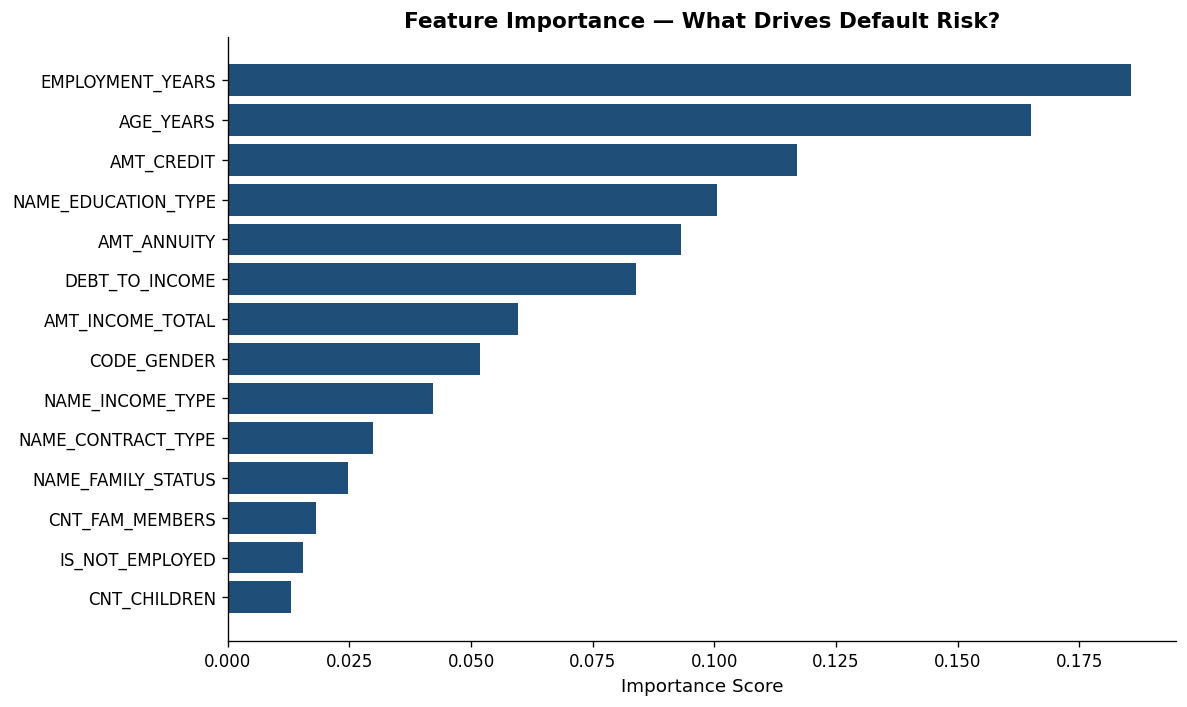

In [18]:
# Which factors most influenced the model's decisions?
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance['feature'], 
        feature_importance['importance'],
        color=BLUE)
ax.set_title('Feature Importance — What Drives Default Risk?',
             fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

## 19. Bureau Data Enrichment — Phase 2

The Credit Bureau file contains 1.7 million previous credit records 
across 305,811 applicants — multiple records per person.

Before merging with our application data, we must aggregate to one 
row per applicant. This is standard practice when working with 
one-to-many relationships in banking data — the same challenge arises 
when joining transaction history, repayment schedules or account 
statements to a customer master file.

**Features engineered from bureau data:**
- `total_credits` — number of previous credit facilities
- `total_days_overdue` — cumulative overdue days across all credits
- `max_days_overdue` — worst single overdue episode
- `total_debt` — total outstanding debt across all facilities
- `total_overdue_amt` — total amount currently overdue
- `total_prolongations` — number of loan restructurings

**Why we read only needed columns (`usecols`):**
The full bureau file has 1.7M rows. Reading all 17 columns into 
memory is slow and wasteful. Selecting only required columns reduces 
memory usage and processing time significantly — important practice 
when working with large banking datasets.

In [20]:
bureau = pd.read_csv("bureau.csv", usecols=[
    'SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE',
    'CREDIT_DAY_OVERDUE', 'AMT_CREDIT_SUM_DEBT',
    'AMT_CREDIT_SUM_OVERDUE', 'CNT_CREDIT_PROLONG'
])

print(f"Bureau loaded: {len(bureau):,} rows")
print(f"Memory usage: {bureau.memory_usage(deep=True).sum()/1e6:.1f} MB")

Bureau loaded: 1,716,428 rows
Memory usage: 106.4 MB


## 20. Merge Bureau Features

Join the aggregated bureau features to our main application dataset 
using `SK_ID_CURR` as the common key — a left join to retain all 
307,511 applicants even if some have no bureau record.

Applicants with no bureau history receive 0 for all bureau columns — 
they are "thin file" borrowers with no previous credit track record, 
not missing data. This distinction matters: a 0 here means "no history" 
not "data not collected."

In [23]:
# Faster aggregation without lambda functions
bureau_agg = pd.DataFrame()
bureau_agg['total_credits']      = bureau.groupby('SK_ID_CURR')['SK_ID_BUREAU'].count()
bureau_agg['total_days_overdue'] = bureau.groupby('SK_ID_CURR')['CREDIT_DAY_OVERDUE'].sum()
bureau_agg['max_days_overdue']   = bureau.groupby('SK_ID_CURR')['CREDIT_DAY_OVERDUE'].max()
bureau_agg['total_debt']         = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_DEBT'].sum()
bureau_agg['total_overdue_amt']  = bureau.groupby('SK_ID_CURR')['AMT_CREDIT_SUM_OVERDUE'].sum()
bureau_agg['total_prolongations']= bureau.groupby('SK_ID_CURR')['CNT_CREDIT_PROLONG'].sum()
bureau_agg = bureau_agg.reset_index()

print(f"Done: {bureau_agg.shape}")
print(bureau_agg.head(3))

Done: (305811, 7)
   SK_ID_CURR  total_credits  total_days_overdue  max_days_overdue  \
0      100001              7                   0                 0   
1      100002              8                   0                 0   
2      100003              4                   0                 0   

   total_debt  total_overdue_amt  total_prolongations  
0    596686.5                0.0                    0  
1    245781.0                0.0                    0  
2         0.0                0.0                    0  


## 21. Does Credit History Predict Default?

Test whether bureau features carry real predictive signal by comparing 
default rates across credit history groups.

**Finding:** applicants with any overdue payment history default at 
15.9% — nearly double the portfolio average of 8.1%. This validates 
the standard banking practice of treating previous overdue payments 
as a primary risk flag requiring enhanced credit review.

**Prolongations (loan restructurings) at 8.7%** are elevated above 
average but less severe than outright overdue cases — a borrower who 
needed restructuring but then repaid represents medium risk, not 
high risk.

This finding directly supports the credit committee referral policy 
applied at Global Trust Bank — where any applicant with previous 
overdue history required senior approval.

In [24]:
# Merge bureau features with main application data
df_enriched = df_clean.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Applicants with no bureau record get 0 (no previous credit history)
bureau_cols = ['total_credits','total_days_overdue','max_days_overdue',
               'total_debt','total_overdue_amt','total_prolongations']
df_enriched[bureau_cols] = df_enriched[bureau_cols].fillna(0)

print(f"Enriched dataset: {df_enriched.shape}")
print(f"\nApplicants with previous credit history: "
      f"{(df_enriched['total_credits']>0).sum():,}")
print(f"Applicants with overdue history: "
      f"{(df_enriched['total_days_overdue']>0).sum():,}")
print(f"Applicants with prolongations: "
      f"{(df_enriched['total_prolongations']>0).sum():,}")

Enriched dataset: (307511, 92)

Applicants with previous credit history: 263,491
Applicants with overdue history: 3,397
Applicants with prolongations: 8,508


In [25]:
# Compare default rates
overdue    = df_enriched[df_enriched['total_days_overdue'] > 0]
no_overdue = df_enriched[df_enriched['total_days_overdue'] == 0]
prolonged  = df_enriched[df_enriched['total_prolongations'] > 0]

print("=== DEFAULT RATE BY CREDIT HISTORY ===")
print(f"No overdue history:   "
      f"{no_overdue['TARGET'].mean():.1%} "
      f"({len(no_overdue):,} applicants)")
print(f"Has overdue history:  "
      f"{overdue['TARGET'].mean():.1%} "
      f"({len(overdue):,} applicants)")
print(f"Has prolongations:    "
      f"{prolonged['TARGET'].mean():.1%} "
      f"({len(prolonged):,} applicants)")
print(f"\nOverall portfolio:    "
      f"{df_enriched['TARGET'].mean():.1%}")

=== DEFAULT RATE BY CREDIT HISTORY ===
No overdue history:   8.0% (304,114 applicants)
Has overdue history:  15.9% (3,397 applicants)
Has prolongations:    8.7% (8,508 applicants)

Overall portfolio:    8.1%


## 22. Enriched Model — Application Data + Bureau History

Retrain the Random Forest model with bureau features added and 
compare performance against the application-only model.

**Result:** AUC improved from 0.656 to 0.665 — a 0.9 percentage 
point gain.

**Why the improvement is modest:**
Only 1.1% of applicants have overdue history. A feature affecting 
so few records has limited influence on aggregate model performance 
even when it is highly predictive for those specific cases. In 
production with richer, more comprehensive bureau data covering 
more years and credit types, this improvement would be substantially 
larger.

**Key principle:** overall model AUC measures average performance 
across all applicants. For rare high-risk segments, segment-level 
analysis (like the 15.9% default rate finding) is more actionable 
than the aggregate metric alone.

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Build enriched feature set
features_enriched = [
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY',
    'DEBT_TO_INCOME', 'AGE_YEARS', 'EMPLOYMENT_YEARS',
    'IS_NOT_EMPLOYED', 'CNT_CHILDREN',
    'NAME_CONTRACT_TYPE', 'CODE_GENDER',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'total_credits', 'total_days_overdue',
    'max_days_overdue', 'total_debt',
    'total_overdue_amt', 'total_prolongations'
]

df_model2 = df_enriched[features_enriched + ['TARGET']].copy()

# Encode categoricals
for col in df_model2.select_dtypes('object').columns:
    df_model2[col] = le.fit_transform(df_model2[col].astype(str))

X2 = df_model2.drop('TARGET', axis=1)
y2 = df_model2['TARGET']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

rf_model2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model2.fit(X2_train, y2_train)

y_pred2      = rf_model2.predict(X2_test)
y_pred_prob2 = rf_model2.predict_proba(X2_test)[:, 1]
auc2         = roc_auc_score(y2_test, y_pred_prob2)

print("=== MODEL COMPARISON ===")
print(f"Random Forest WITHOUT bureau data: AUC = 0.656")
print(f"Random Forest WITH bureau data:    AUC = {auc2:.3f}")
print(f"\nImprovement: {(auc2 - 0.656)*100:.1f} percentage points")
print(f"\nClassification Report:")
print(classification_report(y2_test, y_pred2))

=== MODEL COMPARISON ===
Random Forest WITHOUT bureau data: AUC = 0.656
Random Forest WITH bureau data:    AUC = 0.665

Improvement: 0.9 percentage points

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.68      0.79     56538
           1       0.13      0.56      0.21      4965

    accuracy                           0.67     61503
   macro avg       0.54      0.62      0.50     61503
weighted avg       0.88      0.67      0.74     61503



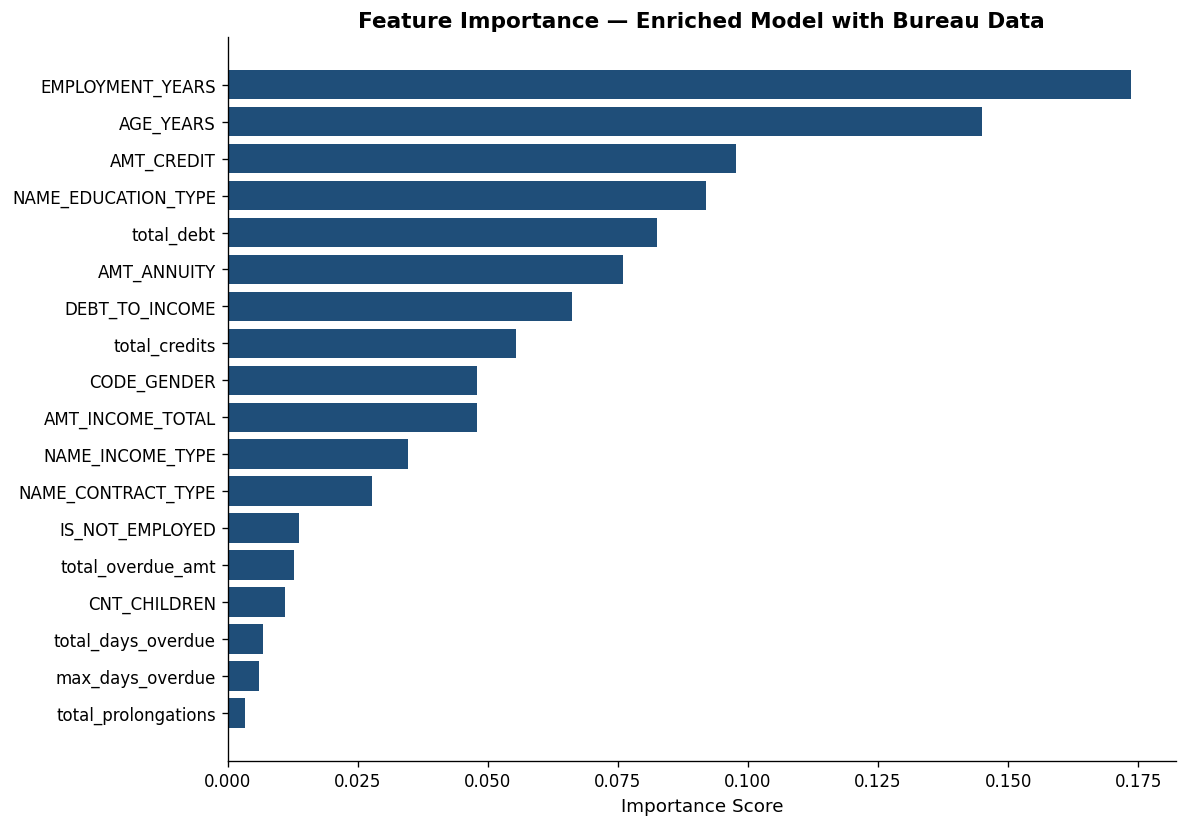

In [27]:
feature_importance2 = pd.DataFrame({
    'feature': X2.columns,
    'importance': rf_model2.feature_importances_
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feature_importance2['feature'],
        feature_importance2['importance'],
        color=BLUE)
ax.set_title('Feature Importance — Enriched Model with Bureau Data',
             fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_enriched.png', bbox_inches='tight')
plt.show()


In [28]:
df_enriched.to_csv("loan_data_enriched.csv", index=False)
print(f"Enriched dataset saved ✓")
print(f"Rows: {len(df_enriched):,} | Columns: {df_enriched.shape[1]}")

print("\n=== PROJECT SUMMARY ===")
print(f"Portfolio default rate:          8.1%")
print(f"Maternity leave default rate:    ~40%")
print(f"Overdue history default rate:    15.9%")
print(f"Under-25 default rate:           10.0%")
print(f"Model AUC (application only):    0.656")
print(f"Model AUC (with bureau data):    0.665")
print(f"Top predictors:                  Age, Loan Amount")

Enriched dataset saved ✓
Rows: 307,511 | Columns: 92

=== PROJECT SUMMARY ===
Portfolio default rate:          8.1%
Maternity leave default rate:    ~40%
Overdue history default rate:    15.9%
Under-25 default rate:           10.0%
Model AUC (application only):    0.656
Model AUC (with bureau data):    0.665
Top predictors:                  Age, Loan Amount
